In [254]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

%matplotlib inline

In [255]:
df_2020 = pd.read_csv('data/nuremberg_2020_20m_polygons.csv')
df_2021 = pd.read_csv('data/nuremberg_2021_20m_polygons.csv')

In [256]:
df_2020.dtypes

system:index                int64
B11                       float64
B12                       float64
B2                        float64
B3                        float64
B4                        float64
B5                        float64
B6                        float64
B7                        float64
B8                        float64
bare_sparse_vegetation    float64
built_up                  float64
cell_id                       str
cropland                  float64
grassland                 float64
image_count                 int64
tree_cover                float64
water                     float64
x                         float64
y                         float64
year                        int64
.geo                          str
dtype: object

In [257]:
df_2020 = df_2020.drop(columns=['system:index', 'image_count', '.geo', 'x', 'y', 'year', 'cell_id'])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['system:index', 'image_count', '.geo', 'x', 'y', 'year', 'cell_id'])
df_2021 = df_2021.fillna(df_2021.mean())

In [258]:
# B1, B9, B10

In [259]:
# mean_median_cols = [col for col in df_2020.columns if ('_median' in col)]
excluded_bands = [col for col in df_2020 if not ('B1_' in col or 'B9_' in col or 'B8A' in col or 'B10_' in col)]

df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

all_target_cols = [
    'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
    # 'herbaceous_wetland', 'mangroves', 'moss_lichen', 'shrubland',
    # 'snow_ice',
    'tree_cover', 'water',
    # 'vegetation'
]

selected_labels = [
    # 'vegetation',
    'built_up',
    'tree_cover', 'grassland', 'cropland',
    # 'bare_sparse_vegetation', 'water'
]

sel_col = excluded_bands
df_2020 = df_2020[sel_col]
df_2021 = df_2021[sel_col]

In [260]:
df_2020.columns

Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'tree_cover', 'water'],
      dtype='str')

In [261]:
"""feature engineering
NDVI = (B8 - B4) / (B8 + B4)
NDBI = (B11 - B8) / (B11 + B8)
NDWI = (B3 - B8) / (B3 + B8)
"""

df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'])
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'])
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'])

df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'])
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'])
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'])

In [262]:
X_train = df_2020.drop(columns=all_target_cols)
# X_train = df_2020[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_train = df_2020[selected_labels]

X_test = df_2021.drop(columns=all_target_cols)
# X_test = df_2021[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_test = df_2021[selected_labels]

In [263]:
X_train.columns, y_train.columns

(Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'NDVI', 'NDBI',
        'NDWI'],
       dtype='str'),
 Index(['built_up', 'tree_cover', 'grassland', 'cropland'], dtype='str'))

In [264]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [265]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR

models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    "Lasso Regression": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=0.1, max_iter=10000))]),
    # "SVR": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("svr", MultiOutputRegressor(SVR(kernel='rbf', C=100, epsilon=0.1)))
    # ]),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
}

results = []
for name, model in models.items():
    res = evaluate_regression_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)


--- Linear Regression ---
Train R2: 0.5109 | Test R2: 0.4668
Train RMSE: 0.2410 | Test RMSE: 0.2558

--- Ridge Regression ---
Train R2: 0.5109 | Test R2: 0.4668
Train RMSE: 0.2410 | Test RMSE: 0.2558

--- Lasso Regression ---
Train R2: 0.2792 | Test R2: 0.2840
Train RMSE: 0.2963 | Test RMSE: 0.2976

--- Random Forest ---
Train R2: 0.6938 | Test R2: 0.5953
Train RMSE: 0.1891 | Test RMSE: 0.2238

--- XGBoost ---
Train R2: 0.7226 | Test R2: 0.6333
Train RMSE: 0.1806 | Test RMSE: 0.2135



In [266]:
summary_df = pd.DataFrame(results).sort_values(by='Test RMSE', ascending=True)
display(summary_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
4,XGBoost,0.180566,0.213538,0.722567,0.633294
3,Random Forest,0.189092,0.223789,0.693826,0.595268
0,Linear Regression,0.240978,0.255804,0.510851,0.466777
1,Ridge Regression,0.240978,0.255806,0.510851,0.466770
2,Lasso Regression,0.296330,0.297583,0.279188,0.283980


In [267]:
selected_labels = [
    'tree_cover', 'built_up', 'grassland', 'cropland',
    'bare_sparse_vegetation', 'water'
]

pd.DataFrame({'mean': df_2020[selected_labels].mean(), 'std': df_2020[selected_labels].std()})

,mean,std
tree_cover,0.366616,0.438404
built_up,0.368465,0.435704
grassland,0.122122,0.287768
cropland,0.107917,0.294285
bare_sparse_vegetation,0.023656,0.119428
water,0.011117,0.098643


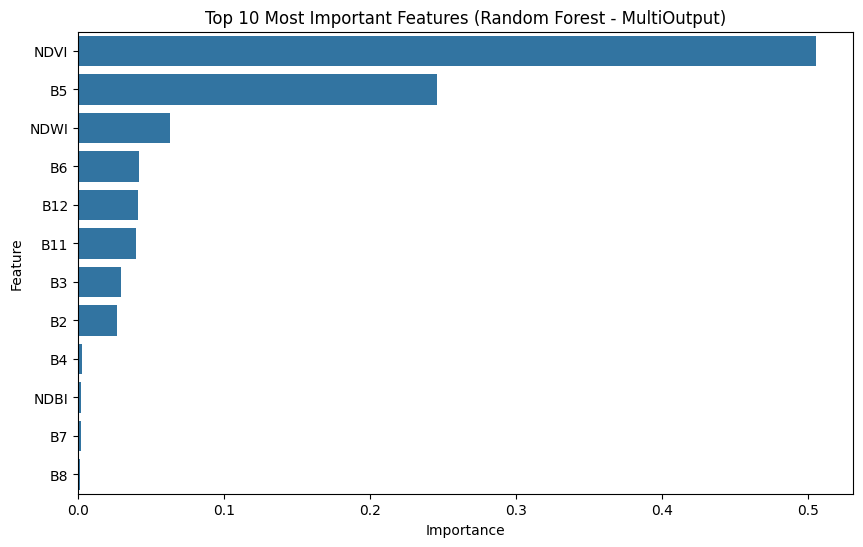

   Feature  Importance
9     NDVI    0.505866
5       B5    0.245683
11    NDWI    0.063002
6       B6    0.041416
1      B12    0.040948
0      B11    0.039468
3       B3    0.029206
2       B2    0.026471
4       B4    0.002795
10    NDBI    0.002150
7       B7    0.001701
8       B8    0.001295


In [268]:
feature_names = X_train.columns
importances = models['Random Forest'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 10 Most Important Features (Random Forest - MultiOutput)')
plt.show()

print(feature_importance_df)

,True_Dominant_Class,Pred_Dominant_Class,Match
0,grassland,tree_cover,False
1,tree_cover,tree_cover,True
2,built_up,built_up,True
3,built_up,built_up,True
4,built_up,built_up,True


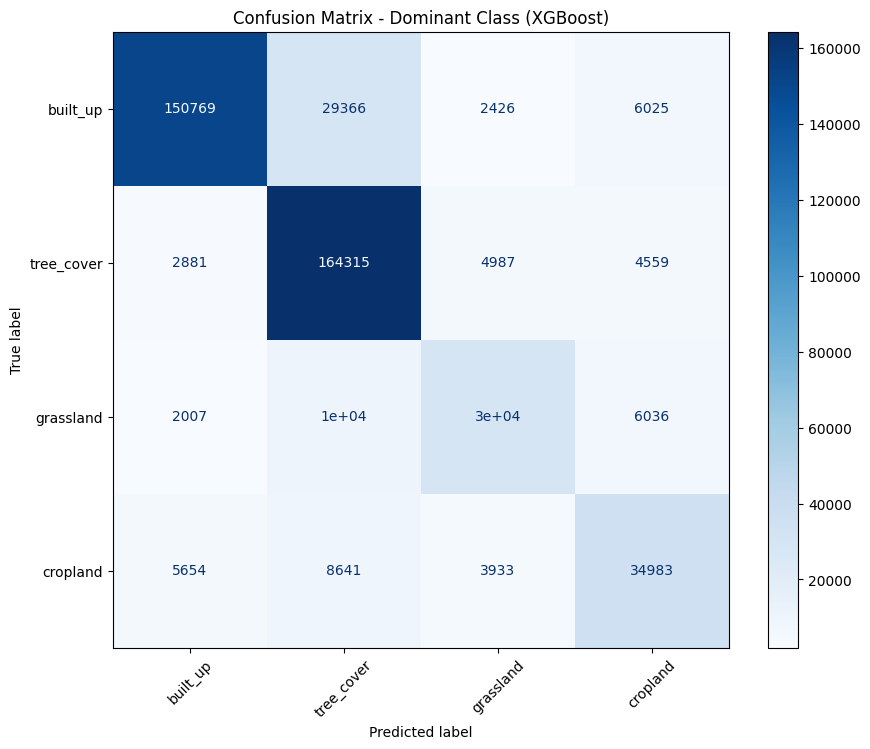

Overall Dominant Class Accuracy: 0.8141


In [269]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Use the labels actually used during training (4 labels in your current code)
current_labels = [
    # 'vegetation',
    'built_up',
    'tree_cover', 'grassland', 'cropland',
    # 'bare_sparse_vegetation', 'water'
]

best_model_name = "XGBoost"
y_pred_array = models[best_model_name].predict(X_test)

# 2. Create DataFrame with the matching 4 columns
y_pred_df = pd.DataFrame(y_pred_array, columns=current_labels)

# 3. Get dominant classes
true_dominant = y_test[current_labels].idxmax(axis=1).reset_index(drop=True)
pred_dominant = y_pred_df.idxmax(axis=1)

# 4. Build comparison table
comparison_df = pd.DataFrame({
    'True_Dominant_Class': true_dominant,
    'Pred_Dominant_Class': pred_dominant
})
comparison_df['Match'] = comparison_df['True_Dominant_Class'] == comparison_df['Pred_Dominant_Class']

# 5. Output results
display(comparison_df.head(5))

# 6. Generate Confusion Matrix
cm = confusion_matrix(true_dominant, pred_dominant, labels=current_labels)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=current_labels)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title(f'Confusion Matrix - Dominant Class ({best_model_name})')
plt.show()

accuracy = comparison_df['Match'].mean()
print(f"Overall Dominant Class Accuracy: {accuracy:.4f}")